### Load df_artists_final

In [1]:
import pandas as pd

df_artists_final = pd.read_csv(
    'df_artists_final.csv',
    index_col=0
)
df_artists_final = df_artists_final.reset_index()

print(df_artists_final.shape)
print(df_artists_final.columns.tolist())

(759, 27)
['years_through_first_top_20_hit', '#_of_charting_songs_through_first_top_20_hit', 'top_20_hit_song_#_wks_on_chart_any_position', 'artist_genre_Blues', 'artist_genre_Classical', 'artist_genre_Country/Americana', 'artist_genre_Easy Listening/Vocal', 'artist_genre_Electronic/Dance', 'artist_genre_Experimental/Avant-Garde', 'artist_genre_Folk', 'artist_genre_Gospel/Christian/Religious', 'artist_genre_Hip Hop/Rap', 'artist_genre_Jazz', 'artist_genre_Latin', 'artist_genre_Metal', 'artist_genre_Pop', 'artist_genre_Punk/Hardcore', 'artist_genre_R&B/Soul/Funk', 'artist_genre_Reggae/Caribbean', 'artist_genre_Rock', 'artist_genre_World Music', 'artist_genre_unknown', '#_of_genres_artist', 'harmonic_closeness_centrality_top20_rolling5', 'betweenness_centrality_top20_rolling5', 'eigenvector_centrality_top20_rolling5', 'top_20_hitmaker']


## Model

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    roc_auc_score, log_loss, brier_score_loss,
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.calibration import calibration_curve
import optuna
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [3]:
# Separate features and target
X = df_artists_final.drop(columns=['top_20_hitmaker'])
y = df_artists_final['top_20_hitmaker']

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print('')
print('y value counts:')
print(y.value_counts())
print('')
print('y class balance:')
print(y.value_counts(normalize=True).round(3))

X shape: (759, 26)
y shape: (759,)

y value counts:
top_20_hitmaker
0.0    431
1.0    328
Name: count, dtype: int64

y class balance:
top_20_hitmaker
0.0    0.568
1.0    0.432
Name: proportion, dtype: float64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}')
print(f'Test:  {X_test.shape}')

Train: (607, 26)
Test:  (152, 26)


In [5]:
# AdaBoost does not natively accept NaN values.
# We impute with column medians, fitting only on the training set to prevent data leakage.

imputer = SimpleImputer(strategy='median')
X_train_clean = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_clean = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print(f'NaN in train: {X_train_clean.isna().sum().sum()}')
print(f'NaN in test:  {X_test_clean.isna().sum().sum()}')

NaN in train: 0
NaN in test:  0


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_clean = pd.DataFrame(
    scaler.fit_transform(X_train_clean),
    columns=X_train_clean.columns,
    index=X_train_clean.index
)
X_test_clean = pd.DataFrame(
    scaler.transform(X_test_clean),
    columns=X_test_clean.columns,
    index=X_test_clean.index
)
print('Features scaled (StandardScaler fit on train only).')

Features scaled (StandardScaler fit on train only).


In [7]:
# Baseline comparison: Dummy classifier vs AdaBoost with default decision tree weak learners.
# AdaBoost here uses DecisionTreeClassifier(max_depth=1) — classic decision stumps.
# This is the original AdaBoost formulation (Freund & Schapire, 1997), unlike ml_sandbox_19_adaboost_linear
# which used linear (SGDClassifier) weak learners.
# Decision stumps can capture non-linear boundaries through ensemble voting,
# while linear weak learners cannot — this is the key difference to explore.
# 5-fold stratified CV to preserve class balance across folds.

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'neg_log_loss']

base_estimator = DecisionTreeClassifier(max_depth=1, random_state=42)

models_baseline = {
    'Dummy':    DummyClassifier(strategy='stratified', random_state=42),
    'AdaBoost': AdaBoostClassifier(estimator=base_estimator, n_estimators=100,
                                   learning_rate=1.0, random_state=42),
}

baseline_results = []
for name, model in models_baseline.items():
    cv = cross_validate(model, X_train_clean, y_train, cv=skf,
                        scoring=scoring, return_train_score=True)
    baseline_results.append({
        'Model':           name,
        'Accuracy':        cv['test_accuracy'].mean(),
        'Precision':       cv['test_precision'].mean(),
        'Recall':          cv['test_recall'].mean(),
        'F1':              cv['test_f1'].mean(),
        'ROC-AUC (CV)':    cv['test_roc_auc'].mean(),
        'ROC-AUC (Train)': cv['train_roc_auc'].mean(),
        'Overfit Gap':     cv['train_roc_auc'].mean() - cv['test_roc_auc'].mean(),
        'Log Loss':        -cv['test_neg_log_loss'].mean(),
    })

df_baseline = pd.DataFrame(baseline_results).set_index('Model').round(3)
print(df_baseline)

          Accuracy  Precision  Recall     F1  ROC-AUC (CV)  ROC-AUC (Train)  \
Model                                                                         
Dummy        0.522      0.444   0.427  0.436         0.511            0.486   
AdaBoost     0.654      0.610   0.558  0.582         0.733            0.824   

          Overfit Gap  Log Loss  
Model                            
Dummy          -0.025    17.220  
AdaBoost        0.090     0.635  


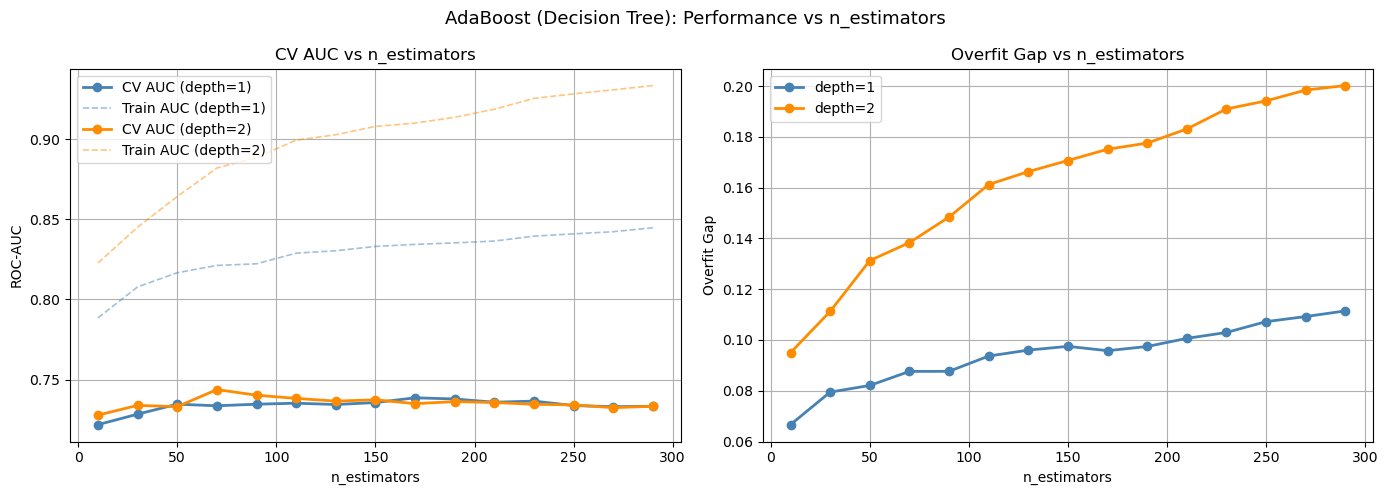

depth=1: best n_estimators=170  CV AUC=0.7386  Gap=0.0958
depth=2: best n_estimators=70  CV AUC=0.7437  Gap=0.1383


In [8]:
# Performance vs n_estimators: evaluate CV AUC and overfit gap at different
# numbers of estimators. Decision tree AdaBoost is more prone to overfitting
# than linear AdaBoost (ml_sandbox_19_adaboost_linear), so this curve may show a clearer peak.
# We test both max_depth=1 (stumps) and max_depth=2 side-by-side.

n_range = list(range(10, 310, 20))
results_by_depth = {}

for depth in [1, 2]:
    depth_results = []
    for n in n_range:
        fold_train_auc, fold_val_auc = [], []
        for train_idx, val_idx in skf.split(X_train_clean, y_train):
            X_tr, X_val = X_train_clean.iloc[train_idx], X_train_clean.iloc[val_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            base = DecisionTreeClassifier(max_depth=depth, random_state=42)
            ada  = AdaBoostClassifier(estimator=base, n_estimators=n,
                                      learning_rate=1.0, random_state=42)
            ada.fit(X_tr, y_tr)
            fold_val_auc.append(roc_auc_score(y_val, ada.predict_proba(X_val)[:, 1]))
            fold_train_auc.append(roc_auc_score(y_tr, ada.predict_proba(X_tr)[:, 1]))
        depth_results.append({
            'n_estimators': n,
            'CV AUC':       np.mean(fold_val_auc),
            'Train AUC':    np.mean(fold_train_auc),
            'Gap':          np.mean(fold_train_auc) - np.mean(fold_val_auc),
        })
    results_by_depth[depth] = pd.DataFrame(depth_results).set_index('n_estimators')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {1: 'steelblue', 2: 'darkorange'}

for depth, df_n in results_by_depth.items():
    axes[0].plot(df_n.index, df_n['CV AUC'], 'o-', color=colors[depth],
                 lw=2, label=f'CV AUC (depth={depth})')
    axes[0].plot(df_n.index, df_n['Train AUC'], '--', color=colors[depth],
                 lw=1.2, alpha=0.5, label=f'Train AUC (depth={depth})')
    axes[1].plot(df_n.index, df_n['Gap'], 'o-', color=colors[depth],
                 lw=2, label=f'depth={depth}')

axes[0].set_xlabel('n_estimators'); axes[0].set_ylabel('ROC-AUC')
axes[0].set_title('CV AUC vs n_estimators'); axes[0].legend(); axes[0].grid(True)
axes[1].set_xlabel('n_estimators'); axes[1].set_ylabel('Overfit Gap')
axes[1].set_title('Overfit Gap vs n_estimators'); axes[1].legend(); axes[1].grid(True)

plt.suptitle('AdaBoost (Decision Tree): Performance vs n_estimators', fontsize=13)
plt.tight_layout()
plt.show()

for depth, df_n in results_by_depth.items():
    best_n = df_n['CV AUC'].idxmax()
    print(f'depth={depth}: best n_estimators={best_n}  CV AUC={df_n["CV AUC"][best_n]:.4f}  Gap={df_n["Gap"][best_n]:.4f}')

  0%|          | 0/100 [00:00<?, ?it/s]

Best params: {'n_estimators': 263, 'learning_rate': 0.012080723811650295, 'max_depth': 2}
CV AUC:      0.7486
Train AUC:   0.7961
Overfit Gap: 0.0475
Logloss:     0.5925
BrierScore:  0.2040


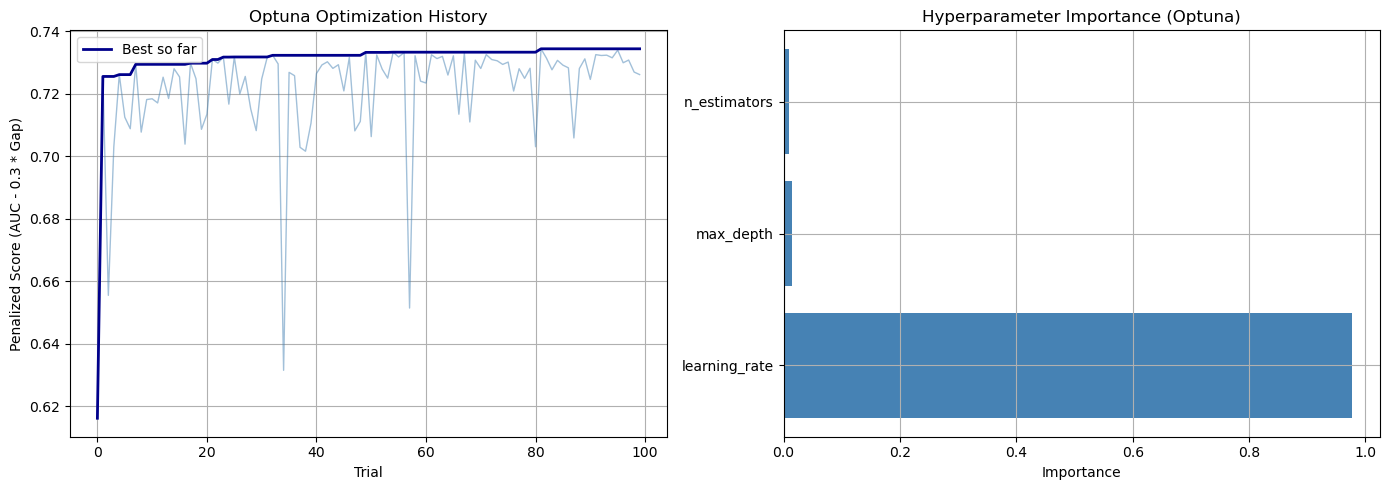

In [9]:
# Hyperparameter tuning with penalized Optuna (lambda=0.3).
# Objective: AUC - lambda * overfit_gap.
# Search space: AdaBoost-level params (n_estimators, learning_rate)
# and decision tree params (max_depth). max_depth controls tree expressiveness
# and is the primary lever for controlling bias-variance tradeoff.
# lambda=0.3: willing to give up 0.01 AUC to reduce the gap by 0.033.

lam = 0.3

def make_objective(X, y, lam):
    def objective(trial):
        n_estimators  = trial.suggest_int('n_estimators', 50, 300)
        learning_rate = trial.suggest_float('learning_rate', 0.01, 2.0, log=True)
        max_depth     = trial.suggest_int('max_depth', 1, 4)

        fold_train_auc, fold_val_auc = [], []
        for train_idx, val_idx in skf.split(X, y):
            X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
            base = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
            ada  = AdaBoostClassifier(
                estimator=base, n_estimators=n_estimators,
                learning_rate=learning_rate, random_state=42
            )
            try:
                ada.fit(X_tr, y_tr)
                fold_val_auc.append(roc_auc_score(y_val, ada.predict_proba(X_val)[:, 1]))
                fold_train_auc.append(roc_auc_score(y_tr, ada.predict_proba(X_tr)[:, 1]))
            except ValueError:
                fold_val_auc.append(np.nan)
                fold_train_auc.append(np.nan)

        val_auc = np.nanmean(fold_val_auc)
        gap     = np.nanmean(fold_train_auc) - val_auc
        return val_auc - lam * gap
    return objective

def cv_evaluate(X, y, params, skf):
    fold_train_auc, fold_val_auc, fold_logloss, fold_brier = [], [], [], []
    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        base = DecisionTreeClassifier(
            max_depth=params.get('max_depth', 1), random_state=42
        )
        ada = AdaBoostClassifier(
            estimator=base,
            n_estimators=params['n_estimators'],
            learning_rate=params['learning_rate'],
            random_state=42
        )
        try:
            ada.fit(X_tr, y_tr)
            proba    = ada.predict_proba(X_val)[:, 1]
            proba_tr = ada.predict_proba(X_tr)[:, 1]
            fold_val_auc.append(roc_auc_score(y_val, proba))
            fold_train_auc.append(roc_auc_score(y_tr, proba_tr))
            fold_logloss.append(log_loss(y_val, proba))
            fold_brier.append(brier_score_loss(y_val, proba))
        except ValueError:
            fold_val_auc.append(np.nan)
            fold_train_auc.append(np.nan)
            fold_logloss.append(np.nan)
            fold_brier.append(np.nan)
    return {
        'CV AUC':      np.nanmean(fold_val_auc),
        'Train AUC':   np.nanmean(fold_train_auc),
        'Overfit Gap': np.nanmean(fold_train_auc) - np.nanmean(fold_val_auc),
        'Logloss':     np.nanmean(fold_logloss),
        'BrierScore':  np.nanmean(fold_brier),
    }

study_full = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_full.optimize(make_objective(X_train_clean, y_train, lam), n_trials=100, show_progress_bar=True)

best_params_full = study_full.best_params
res_full = cv_evaluate(X_train_clean, y_train, best_params_full, skf)

print(f'Best params: {best_params_full}')
print(f'CV AUC:      {res_full["CV AUC"]:.4f}')
print(f'Train AUC:   {res_full["Train AUC"]:.4f}')
print(f'Overfit Gap: {res_full["Overfit Gap"]:.4f}')
print(f'Logloss:     {res_full["Logloss"]:.4f}')
print(f'BrierScore:  {res_full["BrierScore"]:.4f}')

# Optuna optimization history and hyperparameter importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
trial_vals = [t.value for t in study_full.trials if t.value is not None]
axes[0].plot(trial_vals, color='steelblue', alpha=0.5, linewidth=1)
axes[0].plot(np.maximum.accumulate(trial_vals), color='darkblue', linewidth=2, label='Best so far')
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('Penalized Score (AUC - 0.3 * Gap)')
axes[0].set_title('Optuna Optimization History'); axes[0].legend(); axes[0].grid(True)
importances = optuna.importance.get_param_importances(study_full)
axes[1].barh(list(importances.keys()), list(importances.values()), color='steelblue')
axes[1].set_xlabel('Importance'); axes[1].set_title('Hyperparameter Importance (Optuna)')
axes[1].grid(True)
plt.tight_layout()
plt.show()

ROC-AUC (Test):  0.7555
Log Loss:        0.5830
Brier Score:     0.1991
Accuracy:        0.6711
F1:              0.5968
Overfit Gap:     0.0267

              precision    recall  f1-score   support

         0.0       0.69      0.76      0.72        86
         1.0       0.64      0.56      0.60        66

    accuracy                           0.67       152
   macro avg       0.66      0.66      0.66       152
weighted avg       0.67      0.67      0.67       152



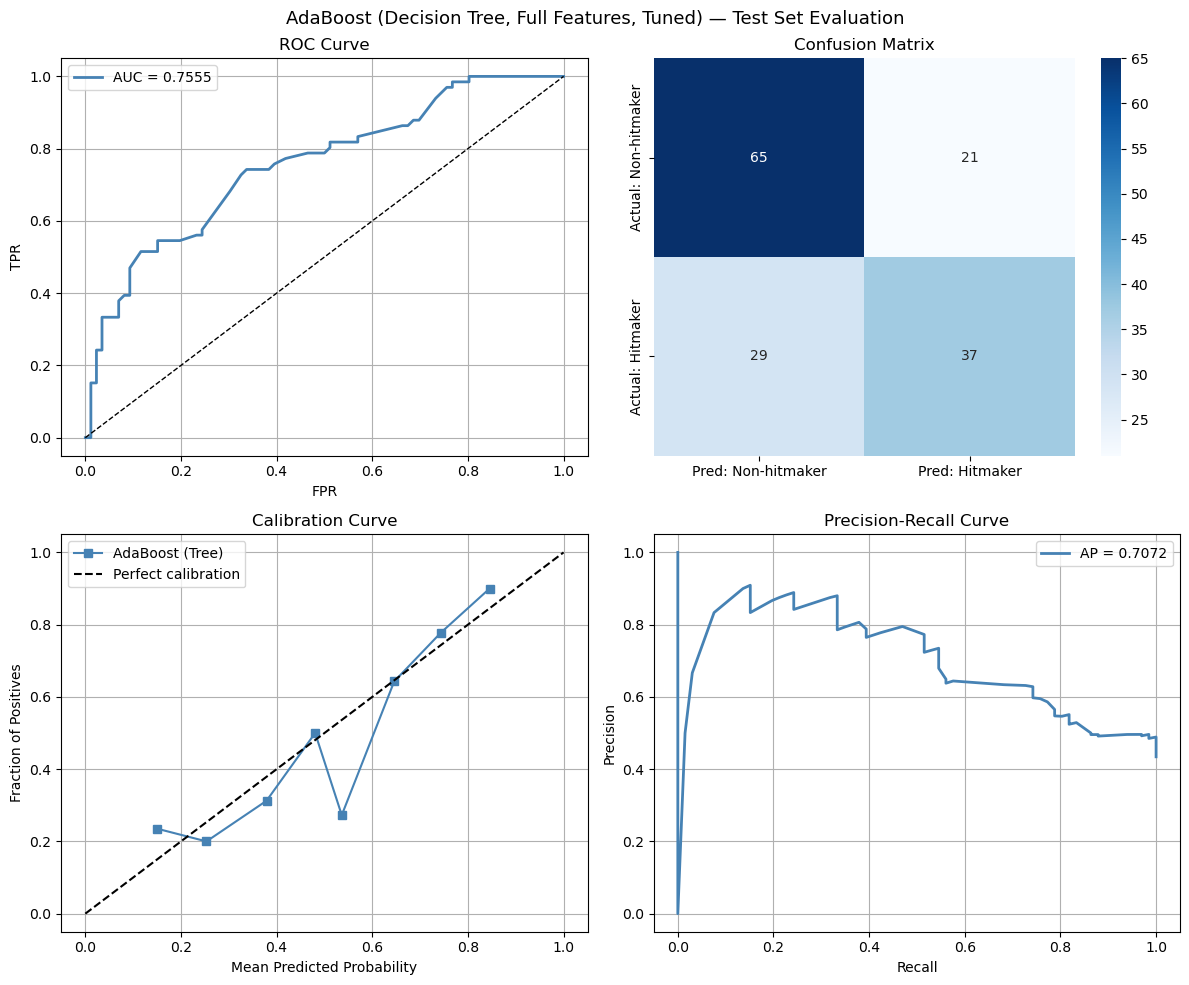

In [10]:
# Fit tuned model on full training set and evaluate on test set.
# Also produce ROC curve, confusion matrix, calibration curve, and PR curve.

def build_model(params):
    base = DecisionTreeClassifier(
        max_depth=params.get('max_depth', 1), random_state=42
    )
    return AdaBoostClassifier(
        estimator=base,
        n_estimators=params['n_estimators'],
        learning_rate=params['learning_rate'],
        random_state=42
    )

ada_full = build_model(best_params_full)
ada_full.fit(X_train_clean, y_train)

y_proba       = ada_full.predict_proba(X_test_clean)[:, 1]
y_pred        = ada_full.predict(X_test_clean)
y_proba_train = ada_full.predict_proba(X_train_clean)[:, 1]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

test_auc_full  = roc_auc_score(y_test, y_proba)
train_auc_full = roc_auc_score(y_train, y_proba_train)
gap_test_full  = train_auc_full - test_auc_full

print(f'ROC-AUC (Test):  {test_auc_full:.4f}')
print(f'Log Loss:        {log_loss(y_test, y_proba):.4f}')
print(f'Brier Score:     {brier_score_loss(y_test, y_proba):.4f}')
print(f'Accuracy:        {accuracy_score(y_test, y_pred):.4f}')
print(f'F1:              {f1_score(y_test, y_pred):.4f}')
print(f'Overfit Gap:     {gap_test_full:.4f}')
print('')
print(classification_report(y_test, y_pred))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0, 0].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {test_auc_full:.4f}')
axes[0, 0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0, 0].set_xlabel('FPR'); axes[0, 0].set_ylabel('TPR')
axes[0, 0].set_title('ROC Curve'); axes[0, 0].legend(); axes[0, 0].grid(True)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1],
            xticklabels=['Pred: Non-hitmaker', 'Pred: Hitmaker'],
            yticklabels=['Actual: Non-hitmaker', 'Actual: Hitmaker'])
axes[0, 1].set_title('Confusion Matrix')

prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
axes[1, 0].plot(prob_pred, prob_true, 's-', color='steelblue', label='AdaBoost (Tree)')
axes[1, 0].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Perfect calibration')
axes[1, 0].set_xlabel('Mean Predicted Probability'); axes[1, 0].set_ylabel('Fraction of Positives')
axes[1, 0].set_title('Calibration Curve'); axes[1, 0].legend(); axes[1, 0].grid(True)

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
axes[1, 1].plot(recall_vals, precision_vals, color='steelblue', lw=2, label=f'AP = {ap:.4f}')
axes[1, 1].set_xlabel('Recall'); axes[1, 1].set_ylabel('Precision')
axes[1, 1].set_title('Precision-Recall Curve'); axes[1, 1].legend(); axes[1, 1].grid(True)

plt.suptitle('AdaBoost (Decision Tree, Full Features, Tuned) — Test Set Evaluation', fontsize=13)
plt.tight_layout()
plt.show()

Permutation importance (mean AUC drop when shuffled):
                                     Feature  Importance      Std
#_of_charting_songs_through_first_top_20_hit    0.145283 0.020276
                          #_of_genres_artist    0.016580 0.004658
       betweenness_centrality_top20_rolling5    0.016245 0.004635
       eigenvector_centrality_top20_rolling5    0.006587 0.005933
              years_through_first_top_20_hit    0.006155 0.001501
                            artist_genre_Pop    0.002928 0.002179
 top_20_hit_song_#_wks_on_chart_any_position    0.001988 0.000732
                        artist_genre_unknown    0.001483 0.001903
harmonic_closeness_centrality_top20_rolling5    0.001203 0.002259
                          artist_genre_Blues    0.000000 0.000000
                           artist_genre_Folk    0.000000 0.000000
       artist_genre_Experimental/Avant-Garde    0.000000 0.000000
               artist_genre_Electronic/Dance    0.000000 0.000000
           artist_genr

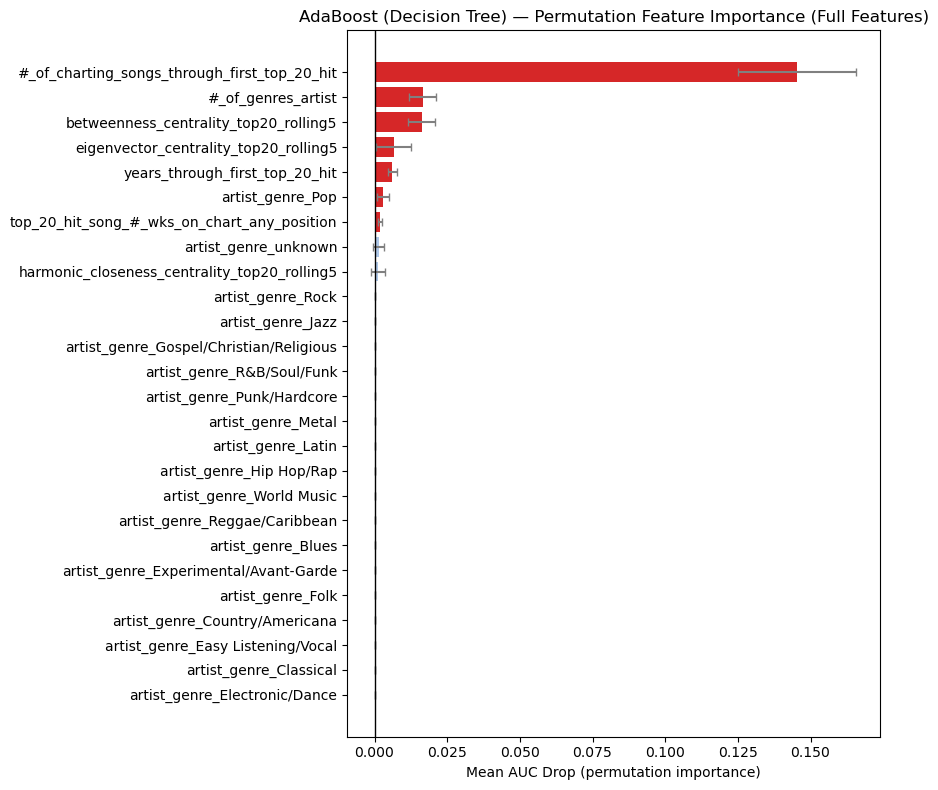

In [11]:
# Permutation importance on the full-feature tuned model.
# Unlike ml_sandbox_19_adaboost_linear (linear AdaBoost), decision tree AdaBoost does expose
# feature_importances_ via the ensemble, but permutation importance is more
# reliable and consistent with ml_sandbox_19_adaboost_linear for direct comparison.
# We compute on the training set to avoid using test data for feature selection.

perm_full = permutation_importance(
    ada_full, X_train_clean, y_train,
    n_repeats=20, random_state=42, scoring='roc_auc'
)

perm_df_full = pd.DataFrame({
    'Feature':    X_train_clean.columns,
    'Importance': perm_full.importances_mean,
    'Std':        perm_full.importances_std,
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print('Permutation importance (mean AUC drop when shuffled):')
print(perm_df_full.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 8))
plot_df = perm_df_full.sort_values('Importance', ascending=True)
colors = ['#d62728' if v >= perm_df_full['Importance'].quantile(0.75) else '#aec7e8'
          for v in plot_df['Importance']]
ax.barh(plot_df['Feature'], plot_df['Importance'], xerr=plot_df['Std'],
        color=colors, error_kw={'ecolor': 'gray', 'capsize': 3})
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Mean AUC Drop (permutation importance)')
ax.set_title('AdaBoost (Decision Tree) — Permutation Feature Importance (Full Features)')
plt.tight_layout()
plt.show()

#### Feature contribution analysis to see which features can be dropped

Baseline (all features)                             AUC: 0.7486  Gap: 0.0475
---------------------------------------------------------------------------
Drop [years_through_first_top_20_hit               ]  AUC: 0.7437 (-0.0049)  Gap: 0.0514 (+0.0039)
Drop [#_of_charting_songs_through_first_top_20_hit ]  AUC: 0.6968 (-0.0518)  Gap: 0.0679 (+0.0204)
Drop [top_20_hit_song_#_wks_on_chart_any_position  ]  AUC: 0.7484 (-0.0002)  Gap: 0.0432 (-0.0043)
Drop [artist_genre_Blues                           ]  AUC: 0.7486 (+0.0000)  Gap: 0.0475 (+0.0000)
Drop [artist_genre_Classical                       ]  AUC: 0.7486 (+0.0000)  Gap: 0.0475 (+0.0000)
Drop [artist_genre_Country/Americana               ]  AUC: 0.7480 (-0.0006)  Gap: 0.0481 (+0.0006)
Drop [artist_genre_Easy Listening/Vocal            ]  AUC: 0.7486 (+0.0000)  Gap: 0.0475 (+0.0000)
Drop [artist_genre_Electronic/Dance                ]  AUC: 0.7486 (+0.0000)  Gap: 0.0475 (+0.0000)
Drop [artist_genre_Experimental/Avant-Garde        ]  A

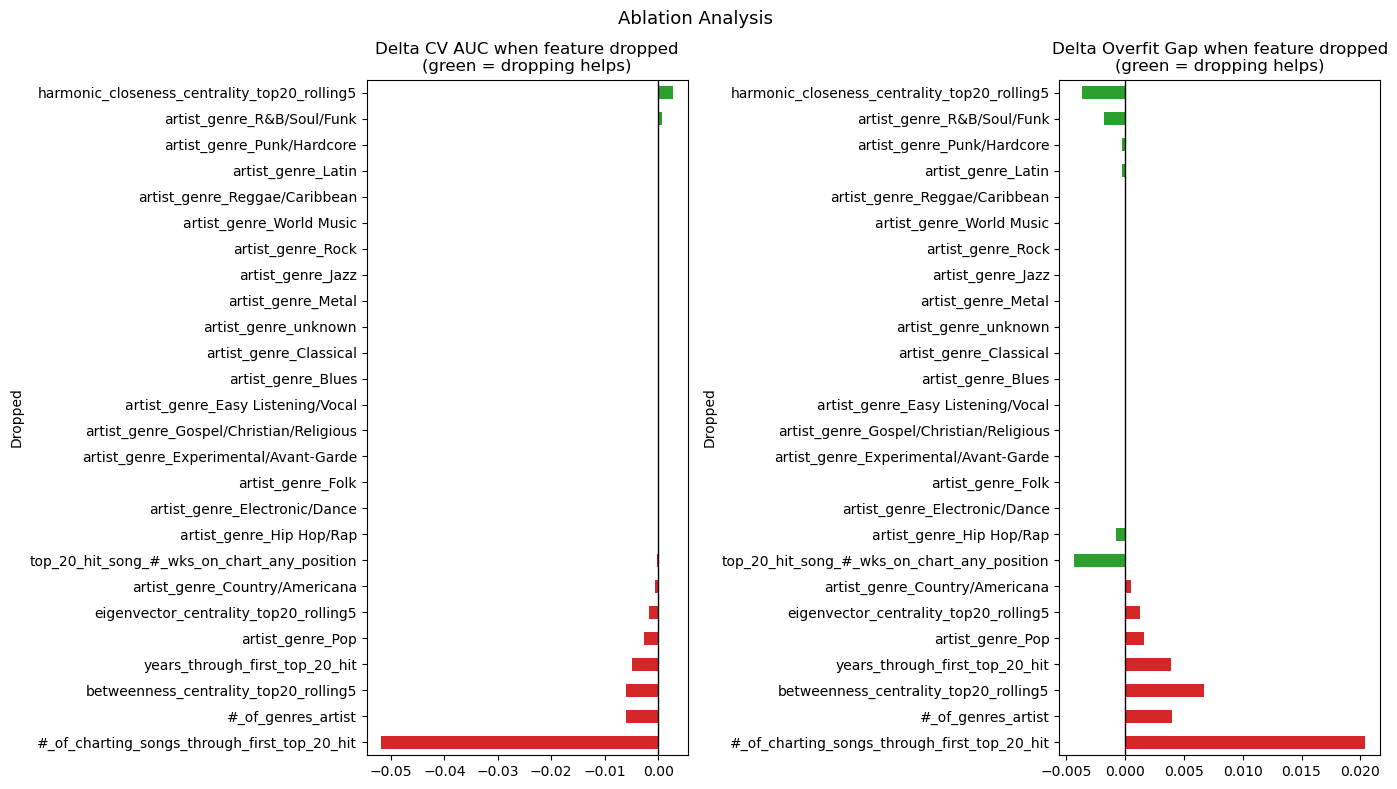

In [12]:
# Ablation analysis: drop each feature one at a time and measure the impact
# on CV AUC and overfit gap. Features with near-zero or positive AUC delta
# when dropped are candidates for removal — they add noise, not signal.
# try/except handles the rare case where AdaBoost fails to converge after
# a critical feature is removed (records NaN for that feature).

def evaluate_features(X, y, params, skf):
    fold_train_auc, fold_val_auc = [], []
    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        ada = build_model(params)
        try:
            ada.fit(X_tr, y_tr)
            fold_val_auc.append(roc_auc_score(y_val, ada.predict_proba(X_val)[:, 1]))
            fold_train_auc.append(roc_auc_score(y_tr, ada.predict_proba(X_tr)[:, 1]))
        except ValueError:
            fold_val_auc.append(np.nan)
            fold_train_auc.append(np.nan)
    return np.nanmean(fold_val_auc), np.nanmean(fold_train_auc) - np.nanmean(fold_val_auc)

baseline_auc, baseline_gap = evaluate_features(X_train_clean, y_train, best_params_full, skf)
print(f'{"Baseline (all features)":50s}  AUC: {baseline_auc:.4f}  Gap: {baseline_gap:.4f}')
print('-' * 75)

ablation_results = []
for feature in X_train_clean.columns:
    X_abl = X_train_clean.drop(columns=[feature])
    auc, gap = evaluate_features(X_abl, y_train, best_params_full, skf)
    delta_auc = auc - baseline_auc
    delta_gap = gap - baseline_gap
    ablation_results.append({
        'Dropped':   feature,
        'CV AUC':    auc,
        'Delta AUC': delta_auc,
        'Gap':       gap,
        'Delta Gap': delta_gap,
    })
    print(f'Drop [{feature[:45]:45s}]  AUC: {auc:.4f} ({delta_auc:+.4f})  Gap: {gap:.4f} ({delta_gap:+.4f})')

df_ablation = pd.DataFrame(ablation_results).set_index('Dropped').sort_values('Delta AUC')

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
auc_colors = ['#2ca02c' if v >= 0 else '#d62728' for v in df_ablation['Delta AUC']]
gap_colors = ['#2ca02c' if v <= 0 else '#d62728' for v in df_ablation['Delta Gap']]
df_ablation['Delta AUC'].plot(kind='barh', ax=axes[0], color=auc_colors)
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('Delta CV AUC when feature dropped\n(green = dropping helps)')
df_ablation['Delta Gap'].plot(kind='barh', ax=axes[1], color=gap_colors)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Delta Overfit Gap when feature dropped\n(green = dropping helps)')
plt.suptitle('Ablation Analysis', fontsize=13)
plt.tight_layout()
plt.show()

High-signal genres (importance > 0): ['artist_genre_Pop', 'artist_genre_unknown']
Features before consolidation: 26
Features after consolidation:  10

Consolidated feature list:
['years_through_first_top_20_hit', '#_of_charting_songs_through_first_top_20_hit', 'top_20_hit_song_#_wks_on_chart_any_position', 'artist_genre_Pop', 'artist_genre_unknown', '#_of_genres_artist', 'harmonic_closeness_centrality_top20_rolling5', 'betweenness_centrality_top20_rolling5', 'eigenvector_centrality_top20_rolling5', 'artist_genre_other']


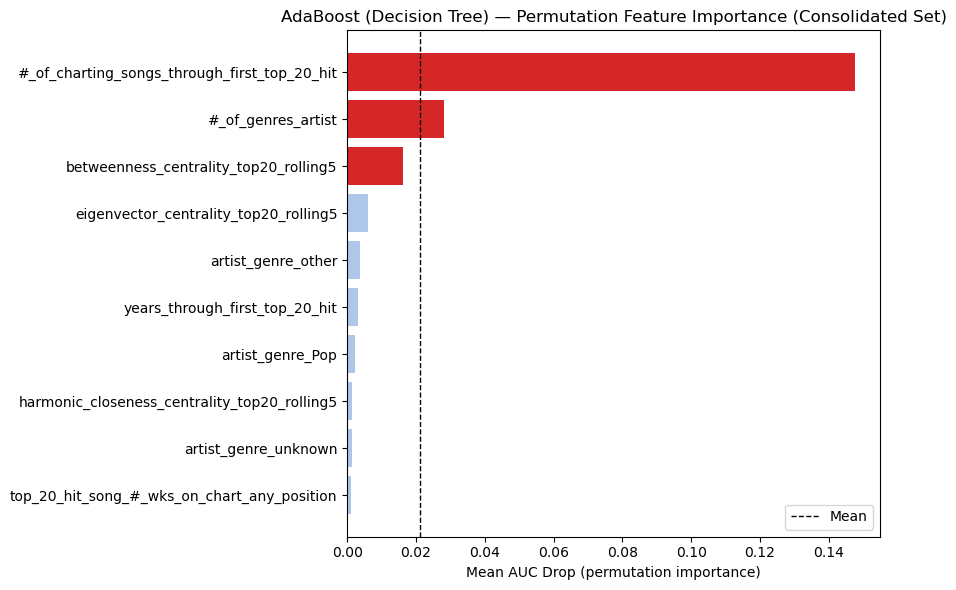


Feature importance order (for forward selection):
                                     Feature  Importance
#_of_charting_songs_through_first_top_20_hit    0.147503
                          #_of_genres_artist    0.028224
       betweenness_centrality_top20_rolling5    0.016160
       eigenvector_centrality_top20_rolling5    0.006023
                          artist_genre_other    0.003657
              years_through_first_top_20_hit    0.003224
                            artist_genre_Pop    0.002126
harmonic_closeness_centrality_top20_rolling5    0.001533
                        artist_genre_unknown    0.001275
 top_20_hit_song_#_wks_on_chart_any_position    0.001007


In [13]:
# Genre consolidation: following ml_sandbox_17_compare_final_xgboost_tuning, ml_sandbox_18_catboost, and ml_sandbox_19_adaboost_linear,
# we consolidate remaining low-signal genre dummies into a single artist_genre_other feature,
# keeping high-signal genres separate (those with permutation importance > 0 in full-feature model).
# This reduces feature noise while preserving genre signal as a consolidated binary flag.

# Derive high-signal genres from full-feature permutation importance (previous cell)
all_genre_cols = [c for c in X_train_clean.columns if c.startswith('artist_genre_')]
genre_imp = (
    perm_df_full[perm_df_full['Feature'].isin(all_genre_cols)]
    .set_index('Feature')['Importance']
)
high_signal_genres = genre_imp[genre_imp > 0].index.tolist()
print(f'High-signal genres (importance > 0): {high_signal_genres}')

low_signal_genres = [c for c in all_genre_cols if c not in high_signal_genres]

X_train_cons = X_train_clean.drop(columns=low_signal_genres).copy()
X_train_cons['artist_genre_other'] = (X_train_clean[low_signal_genres].sum(axis=1) > 0).astype(int)
X_test_cons  = X_test_clean.drop(columns=low_signal_genres).copy()
X_test_cons['artist_genre_other']  = (X_test_clean[low_signal_genres].sum(axis=1) > 0).astype(int)

print(f'Features before consolidation: {X_train_clean.shape[1]}')
print(f'Features after consolidation:  {X_train_cons.shape[1]}')
print('')
print('Consolidated feature list:')
print(X_train_cons.columns.tolist())

# Permutation importance on consolidated set — used to guide forward selection order
ada_cons = build_model(best_params_full)
ada_cons.fit(X_train_cons, y_train)

perm_cons = permutation_importance(
    ada_cons, X_train_cons, y_train,
    n_repeats=20, random_state=42, scoring='roc_auc'
)
feat_imp_cons = pd.DataFrame({
    'Feature':    X_train_cons.columns,
    'Importance': perm_cons.importances_mean,
}).sort_values('Importance', ascending=False).reset_index(drop=True)

feature_order = feat_imp_cons['Feature'].tolist()

fig, ax = plt.subplots(figsize=(9, 6))
feat_imp_plot = feat_imp_cons.sort_values('Importance', ascending=True)
colors = ['#d62728' if v >= feat_imp_cons['Importance'].quantile(0.75) else '#aec7e8'
          for v in feat_imp_plot['Importance']]
ax.barh(feat_imp_plot['Feature'], feat_imp_plot['Importance'], color=colors)
ax.axvline(feat_imp_cons['Importance'].mean(), color='black', linestyle='--',
           linewidth=1, label='Mean')
ax.set_xlabel('Mean AUC Drop (permutation importance)')
ax.set_title('AdaBoost (Decision Tree) — Permutation Feature Importance (Consolidated Set)')
ax.legend()
plt.tight_layout()
plt.show()

print('')
print('Feature importance order (for forward selection):')
print(feat_imp_cons.to_string(index=False))

### Re-tuning AdaBoost (Decision Tree) with genre consolidation and forward feature selection

n= 3  +[betweenness_centrality_top20_rolling5   ]  AUC: 0.7487  Gap: 0.0258
n= 4  +[eigenvector_centrality_top20_rolling5   ]  AUC: 0.7515  Gap: 0.0304
n= 5  +[artist_genre_other                      ]  AUC: 0.7526  Gap: 0.0325
n= 6  +[years_through_first_top_20_hit          ]  AUC: 0.7532  Gap: 0.0349
n= 7  +[artist_genre_Pop                        ]  AUC: 0.7550  Gap: 0.0353
n= 8  +[harmonic_closeness_centrality_top20_roll]  AUC: 0.7496  Gap: 0.0415
n= 9  +[artist_genre_unknown                    ]  AUC: 0.7496  Gap: 0.0415
n=10  +[top_20_hit_song_#_wks_on_chart_any_posit]  AUC: 0.7501  Gap: 0.0455


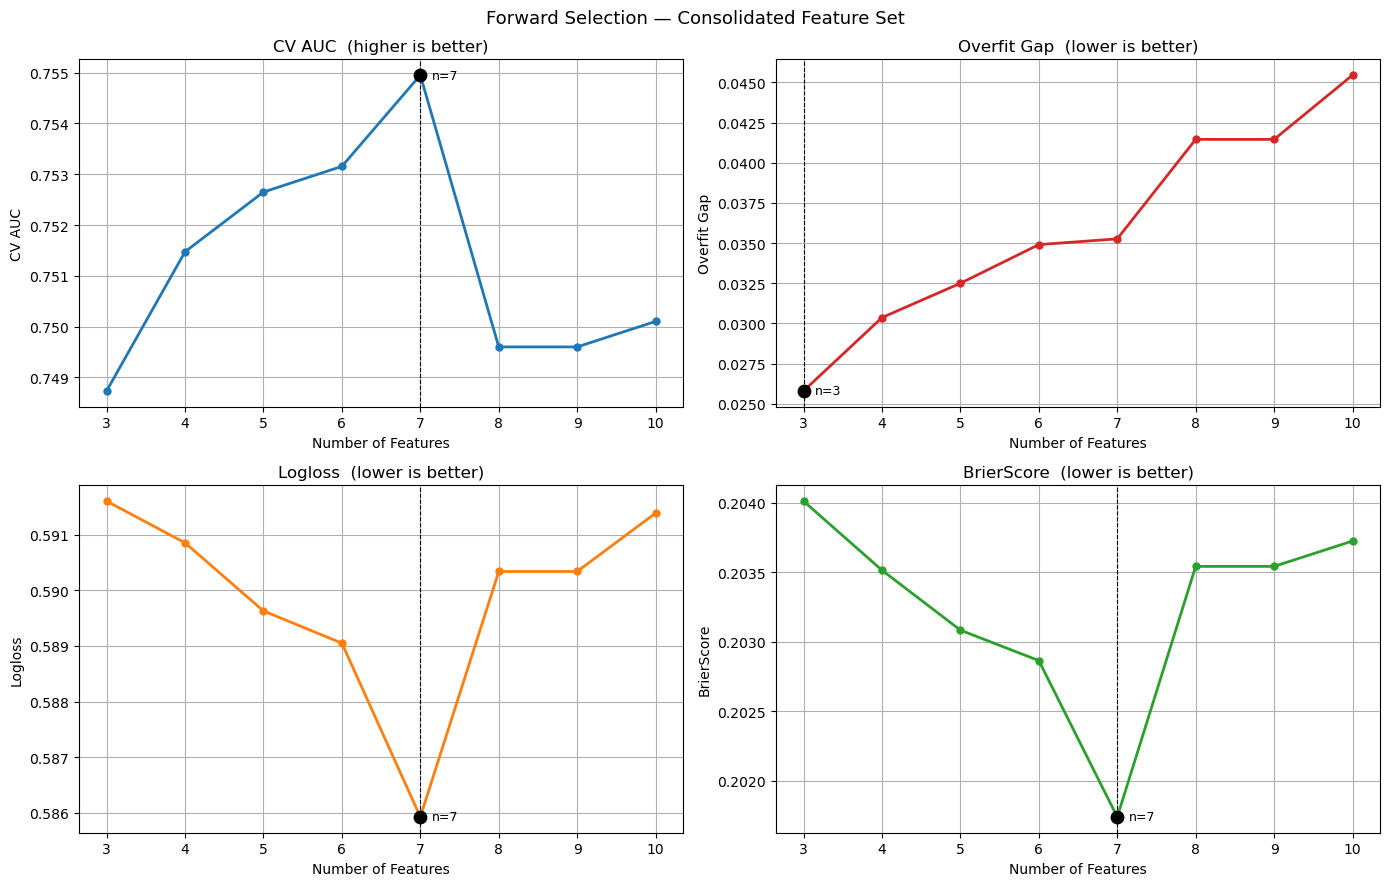


            CV AUC  Overfit Gap  Logloss  BrierScore
n_features                                          
3           0.7487       0.0258   0.5916      0.2040
4           0.7515       0.0304   0.5909      0.2035
5           0.7526       0.0325   0.5896      0.2031
6           0.7532       0.0349   0.5890      0.2029
7           0.7550       0.0353   0.5859      0.2017
8           0.7496       0.0415   0.5903      0.2035
9           0.7496       0.0415   0.5903      0.2035
10          0.7501       0.0455   0.5914      0.2037


In [14]:
# Forward feature selection: start with top 3 features (by permutation importance)
# and add one at a time. Track CV AUC, overfit gap, Logloss, and BrierScore
# to find the optimal feature count.

sel_results = []
for n_feats in range(3, len(feature_order) + 1):
    feats = feature_order[:n_feats]
    X_sub = X_train_cons[feats]
    fold_train_auc, fold_val_auc, fold_logloss, fold_brier = [], [], [], []
    for train_idx, val_idx in skf.split(X_sub, y_train):
        X_tr, X_val = X_sub.iloc[train_idx], X_sub.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        ada = build_model(best_params_full)
        try:
            ada.fit(X_tr, y_tr)
            proba    = ada.predict_proba(X_val)[:, 1]
            proba_tr = ada.predict_proba(X_tr)[:, 1]
            fold_val_auc.append(roc_auc_score(y_val, proba))
            fold_train_auc.append(roc_auc_score(y_tr, proba_tr))
            fold_logloss.append(log_loss(y_val, proba))
            fold_brier.append(brier_score_loss(y_val, proba))
        except ValueError:
            fold_val_auc.append(np.nan); fold_train_auc.append(np.nan)
            fold_logloss.append(np.nan); fold_brier.append(np.nan)
    val_auc   = np.nanmean(fold_val_auc)
    train_auc = np.nanmean(fold_train_auc)
    sel_results.append({
        'n_features':  n_feats,
        'last_added':  feature_order[n_feats - 1],
        'CV AUC':      val_auc,
        'Train AUC':   train_auc,
        'Overfit Gap': train_auc - val_auc,
        'Logloss':     np.nanmean(fold_logloss),
        'BrierScore':  np.nanmean(fold_brier),
    })
    print(f'n={n_feats:2d}  +[{feature_order[n_feats-1][:40]:40s}]  AUC: {val_auc:.4f}  Gap: {train_auc-val_auc:.4f}')

df_sel = pd.DataFrame(sel_results).set_index('n_features')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (metric, color, better) in zip(axes.flat, [
    ('CV AUC',      '#1f77b4', 'higher'),
    ('Overfit Gap', '#d62728', 'lower'),
    ('Logloss',     '#ff7f0e', 'lower'),
    ('BrierScore',  '#2ca02c', 'lower'),
]):
    ax.plot(df_sel.index, df_sel[metric], 'o-', color=color, linewidth=2, markersize=5)
    best_n   = df_sel[metric].idxmax() if better == 'higher' else df_sel[metric].idxmin()
    best_val = df_sel[metric][best_n]
    ax.scatter([best_n], [best_val], color='black', zorder=5, s=80)
    ax.axvline(best_n, color='black', linestyle='--', linewidth=0.8)
    ax.text(best_n + 0.15, best_val, f'n={best_n}', fontsize=9, va='center')
    ax.set_xlabel('Number of Features'); ax.set_ylabel(metric)
    ax.set_title(f'{metric}  ({"higher" if better == "higher" else "lower"} is better)')
    ax.grid(True)
plt.suptitle('Forward Selection — Consolidated Feature Set', fontsize=13)
plt.tight_layout()
plt.show()

print('')
print(df_sel[['CV AUC', 'Overfit Gap', 'Logloss', 'BrierScore']].round(4).to_string())

In [15]:
# Re-tune with penalized Optuna (lambda=0.3) on two candidate feature subsets.
# n_auc: maximises CV AUC; n_gap: minimises overfit gap.
# Re-tuning each subset separately lets hyperparameters adapt to the new feature space.

n_auc = df_sel['CV AUC'].idxmax()
n_gap = df_sel['Overfit Gap'].idxmin()
candidate_ns = sorted(set([n_auc, n_gap]))
print(f'n_auc={n_auc}, n_gap={n_gap}, running candidates: {candidate_ns}')

optuna_studies   = {}
best_params_by_n = {}
cv_results_by_n  = {}
X_train_by_n     = {n: X_train_cons[feature_order[:n]] for n in candidate_ns}
X_test_by_n      = {n: X_test_cons[feature_order[:n]]  for n in candidate_ns}

for n in candidate_ns:
    print(f'\n--- Optuna: n={n} features ---')
    print('  Features:', feature_order[:n])
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
    study.optimize(make_objective(X_train_by_n[n], y_train, lam),
                   n_trials=100, show_progress_bar=True)
    optuna_studies[n]   = study
    best_params_by_n[n] = study.best_params
    cv_results_by_n[n]  = cv_evaluate(X_train_by_n[n], y_train, study.best_params, skf)
    res = cv_results_by_n[n]
    print(f'  CV AUC:      {res["CV AUC"]:.4f}')
    print(f'  Train AUC:   {res["Train AUC"]:.4f}')
    print(f'  Overfit Gap: {res["Overfit Gap"]:.4f}')
    print(f'  Logloss:     {res["Logloss"]:.4f}')
    print(f'  BrierScore:  {res["BrierScore"]:.4f}')

# Summary table
print('\n--- CV Summary ---')
df_cv_summary = pd.DataFrame({n: cv_results_by_n[n] for n in candidate_ns}).T.round(4)
df_cv_summary.index.name = 'n_features'
print(df_cv_summary.to_string())

# Auto-select n_optimal from re-tune results: penalized score = AUC - lambda * Gap
df_cv_summary['penalized'] = df_cv_summary['CV AUC'] - lam * df_cv_summary['Overfit Gap']
n_optimal = df_cv_summary['penalized'].idxmax()

top_features  = feature_order[:n_optimal]
X_train_final = X_train_by_n[n_optimal]
X_test_final  = X_test_by_n[n_optimal]
best_params_final = best_params_by_n[n_optimal]

print(f'\nSelected n_optimal = {n_optimal} (penalized score: AUC - {lam} * Gap)')
print(df_cv_summary[['CV AUC', 'Overfit Gap', 'penalized']].to_string())

n_auc=7, n_gap=3, running candidates: [3, 7]

--- Optuna: n=3 features ---
  Features: ['#_of_charting_songs_through_first_top_20_hit', '#_of_genres_artist', 'betweenness_centrality_top20_rolling5']


  0%|          | 0/100 [00:00<?, ?it/s]

  CV AUC:      0.7506
  Train AUC:   0.7747
  Overfit Gap: 0.0241
  Logloss:     0.5883
  BrierScore:  0.2028

--- Optuna: n=7 features ---
  Features: ['#_of_charting_songs_through_first_top_20_hit', '#_of_genres_artist', 'betweenness_centrality_top20_rolling5', 'eigenvector_centrality_top20_rolling5', 'artist_genre_other', 'years_through_first_top_20_hit', 'artist_genre_Pop']


  0%|          | 0/100 [00:00<?, ?it/s]

  CV AUC:      0.7569
  Train AUC:   0.7923
  Overfit Gap: 0.0353
  Logloss:     0.5838
  BrierScore:  0.2007

--- CV Summary ---
            CV AUC  Train AUC  Overfit Gap  Logloss  BrierScore
n_features                                                     
3           0.7506     0.7747       0.0241   0.5883      0.2028
7           0.7569     0.7923       0.0353   0.5838      0.2007

Selected n_optimal = 7 (penalized score: AUC - 0.3 * Gap)
            CV AUC  Overfit Gap  penalized
n_features                                
3           0.7506       0.0241    0.74337
7           0.7569       0.0353    0.74631


In [16]:
# Compare all AdaBoost (Decision Tree) candidates on the held-out test set.
# AdaBoost (linear, ml_sandbox_19_adaboost_linear), CatBoost (ml_sandbox_18_catboost), and XGBoost (ml_sandbox_17_compare)
# results are included as references.
# All models are fit on the full training set and evaluated once on the test set.

def test_evaluate(model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    proba_te = model.predict_proba(X_te)[:, 1]
    proba_tr = model.predict_proba(X_tr)[:, 1]
    return {
        'Test AUC':    roc_auc_score(y_te, proba_te),
        'Train AUC':   roc_auc_score(y_tr, proba_tr),
        'Overfit Gap': roc_auc_score(y_tr, proba_tr) - roc_auc_score(y_te, proba_te),
        'Logloss':     log_loss(y_te, proba_te),
        'BrierScore':  brier_score_loss(y_te, proba_te),
    }

candidates = {
    'AdaBoost Tree (all 26 features)': (
        build_model(best_params_full),
        X_train_clean, X_test_clean
    ),
    f'AdaBoost Tree (consolidated n={n_optimal})': (
        build_model(best_params_final),
        X_train_final, X_test_final
    ),
}

test_results = []
for name, (model, X_tr, X_te) in candidates.items():
    res = test_evaluate(model, X_tr, y_train, X_te, y_test)
    res['Model']      = name
    res['N Features'] = X_tr.shape[1]
    test_results.append(res)
    print(f'{name}: AUC={res["Test AUC"]:.4f}  Gap={res["Overfit Gap"]:.4f}  Logloss={res["Logloss"]:.4f}  Brier={res["BrierScore"]:.4f}')

# Reference results from prior notebooks
test_results.append({
    'Model':       'AdaBoost Linear (ml_sandbox_19, consolidated n=5)',
    'Test AUC':    0.746,
    'Train AUC':   0.753,
    'Overfit Gap': 0.007,
    'Logloss':     0.607,
    'BrierScore':  0.207,
    'N Features':  5,
})
test_results.append({
    'Model':       'CatBoost (ml_sandbox_18_catboost, consolidated n=12)',
    'Test AUC':    0.770,
    'Train AUC':   0.791,
    'Overfit Gap': 0.022,
    'Logloss':     0.576,
    'BrierScore':  0.195,
    'N Features':  12,
})
# XGBoost (tight regularization) from ml_sandbox_17_compare_final_xgboost_tuning
test_results.append({
    'Model': 'XGBoost (ml_sandbox_17_compare)', 'Test AUC': 0.757,
    'Train AUC': 0.771, 'Overfit Gap': 0.015,
    'Logloss': 0.593, 'BrierScore': 0.203, 'N Features': 10,
})

df_comparison = pd.DataFrame(test_results).set_index('Model').round(4)
print('')
print('--- Final Comparison ---')
print(df_comparison[['Test AUC', 'Overfit Gap', 'Logloss', 'BrierScore', 'N Features']].to_string())

AdaBoost Tree (all 26 features): AUC=0.7555  Gap=0.0267  Logloss=0.5830  Brier=0.1991
AdaBoost Tree (consolidated n=7): AUC=0.7582  Gap=0.0288  Logloss=0.5755  Brier=0.1955

--- Final Comparison ---
                                                      Test AUC  Overfit Gap  Logloss  BrierScore  N Features
Model                                                                                                       
AdaBoost Tree (all 26 features)                         0.7555       0.0267   0.5830      0.1991          26
AdaBoost Tree (consolidated n=7)                        0.7582       0.0288   0.5755      0.1955           7
AdaBoost Linear (ml_sandbox_19, consolidated n=5)       0.7460       0.0070   0.6070      0.2070           5
CatBoost (ml_sandbox_18_catboost, consolidated n=12)    0.7700       0.0220   0.5760      0.1950          12
XGBoost (ml_sandbox_17_compare)                         0.7570       0.0150   0.5930      0.2030          10


## Final model analysis

  FINAL MODEL -- AdaBoost Tree (consolidated n=7)
  Features:       7
  Test samples:   152  (train: 607)

  -- Test --
  ROC-AUC:        0.7582
  Avg Precision:  0.7154
  Log Loss:       0.5755
  Brier Score:    0.1955
  Accuracy:       0.7171
  F1:             0.6614
  Precision:      0.6885
  Recall:         0.6364
  TP=42  FP=19  FN=24  TN=67

  -- Train --
  ROC-AUC:        0.7870
  Log Loss:       0.5484

  -- Overfit Gap --
  Train AUC - Test AUC: 0.0288

                precision    recall  f1-score   support

One-hit Wonder       0.74      0.78      0.76        86
      Hitmaker       0.69      0.64      0.66        66

      accuracy                           0.72       152
     macro avg       0.71      0.71      0.71       152
  weighted avg       0.72      0.72      0.72       152



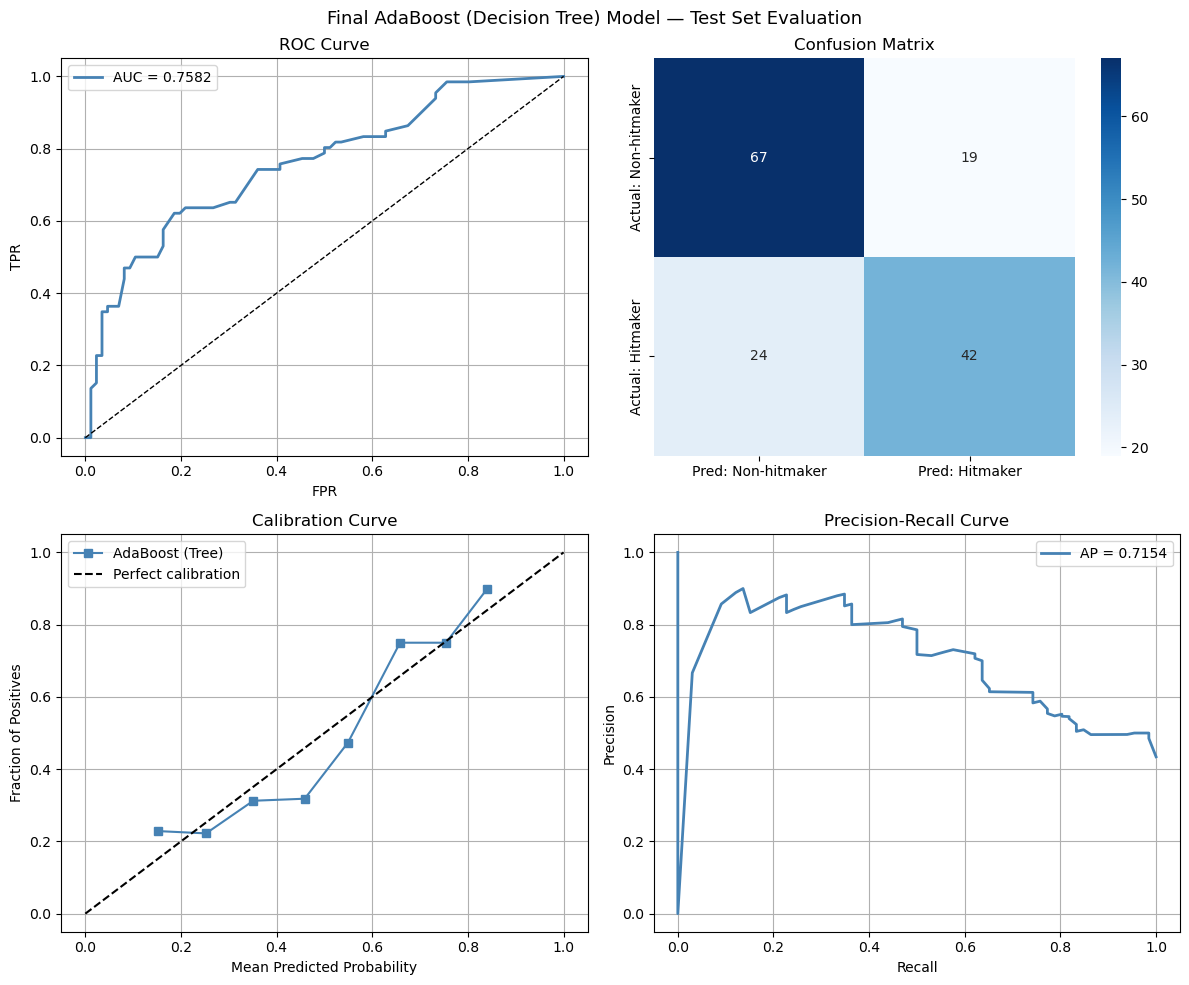

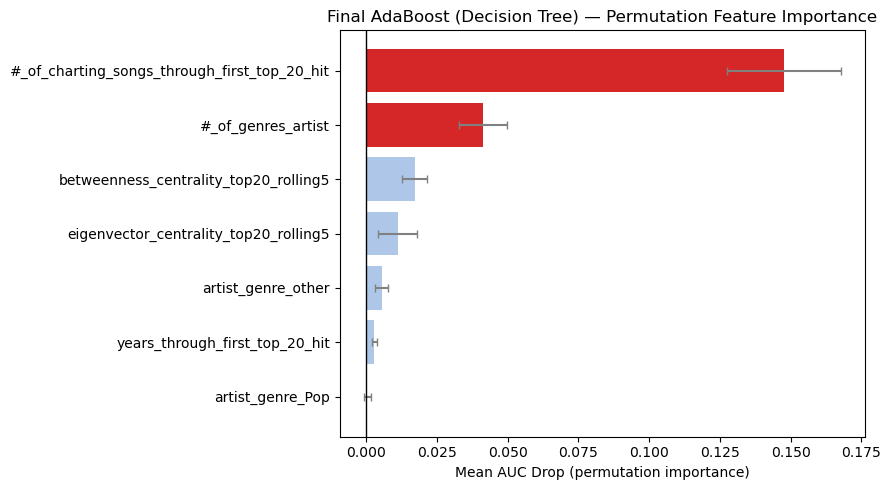


Feature direction (based on mean feature value for hitmakers vs non-hitmakers):
                                              Perm Importance  Mean (hitmakers)  Mean (non-hitmakers)          Direction
#_of_charting_songs_through_first_top_20_hit           0.1478            0.2562               -0.1945  Higher → Hitmaker
#_of_genres_artist                                     0.0413            0.2275               -0.1728  Higher → Hitmaker
betweenness_centrality_top20_rolling5                  0.0172            0.2584               -0.1962  Higher → Hitmaker
eigenvector_centrality_top20_rolling5                  0.0111            0.3026               -0.2298  Higher → Hitmaker
artist_genre_other                                     0.0054            0.3473                0.3391  Higher → Hitmaker
years_through_first_top_20_hit                         0.0029            0.0146               -0.0111  Higher → Hitmaker
artist_genre_Pop                                       0.0004           

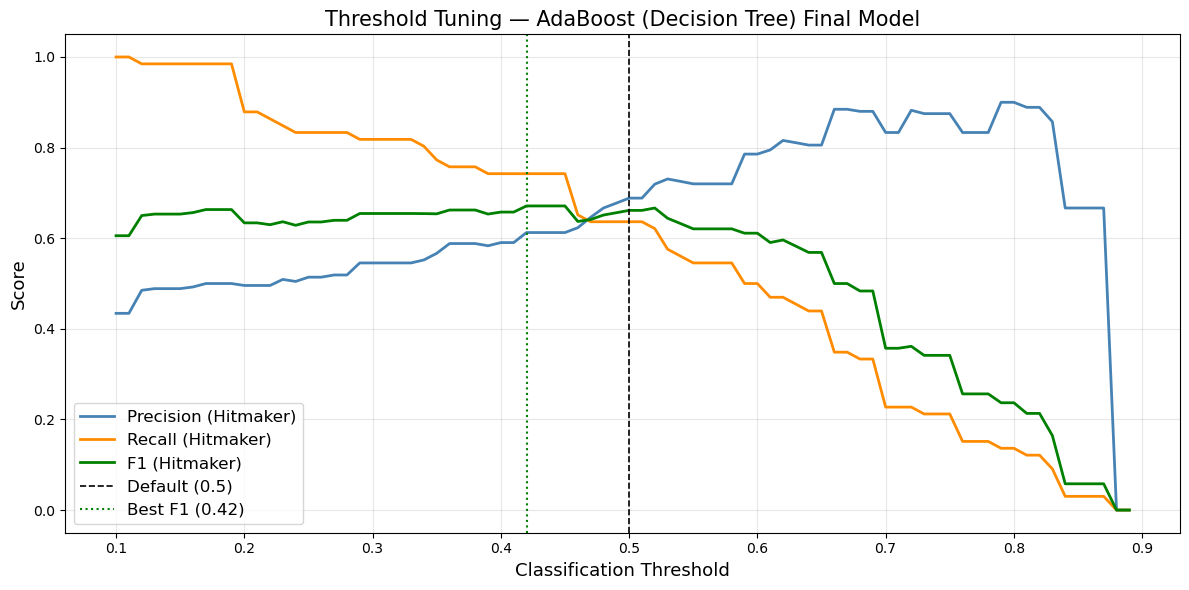


 Threshold  Precision   Recall       F1
------------------------------------------
      0.35      0.567    0.773    0.654
      0.40      0.590    0.742    0.658
      0.45      0.613    0.742    0.671
      0.50      0.689    0.636    0.661
      0.42      0.613    0.742    0.671


In [17]:
# Final model: AdaBoost (Decision Tree) consolidated n=optimal, fitted on the full training set.
# Evaluation on the held-out test set with full metrics, plots, and permutation importance.
# Feature direction table inferred from mean feature value for hitmakers vs non-hitmakers.

ada_model_final = build_model(best_params_final)
ada_model_final.fit(X_train_final, y_train)

y_proba       = ada_model_final.predict_proba(X_test_final)[:, 1]
y_pred        = ada_model_final.predict(X_test_final)
y_proba_train = ada_model_final.predict_proba(X_train_final)[:, 1]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print('=' * 60)
print(f'  FINAL MODEL -- AdaBoost Tree (consolidated n={n_optimal})')
print('=' * 60)
print(f'  Features:       {len(top_features)}')
print(f'  Test samples:   {len(y_test)}  (train: {len(y_train)})')
print('')
print('  -- Test --')
print(f'  ROC-AUC:        {roc_auc_score(y_test, y_proba):.4f}')
print(f'  Avg Precision:  {average_precision_score(y_test, y_proba):.4f}')
print(f'  Log Loss:       {log_loss(y_test, y_proba):.4f}')
print(f'  Brier Score:    {brier_score_loss(y_test, y_proba):.4f}')
print(f'  Accuracy:       {accuracy_score(y_test, y_pred):.4f}')
print(f'  F1:             {f1_score(y_test, y_pred):.4f}')
print(f'  Precision:      {precision_score(y_test, y_pred):.4f}')
print(f'  Recall:         {recall_score(y_test, y_pred):.4f}')
print(f'  TP={tp}  FP={fp}  FN={fn}  TN={tn}')
print('')
print('  -- Train --')
print(f'  ROC-AUC:        {roc_auc_score(y_train, y_proba_train):.4f}')
print(f'  Log Loss:       {log_loss(y_train, y_proba_train):.4f}')
print('')
print('  -- Overfit Gap --')
print(f'  Train AUC - Test AUC: {roc_auc_score(y_train, y_proba_train) - roc_auc_score(y_test, y_proba):.4f}')
print('')
print(classification_report(y_test, y_pred, target_names=['One-hit Wonder', 'Hitmaker']))

# Figure 1: ROC, Confusion Matrix, Calibration, PR curve
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0, 0].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc_score(y_test, y_proba):.4f}')
axes[0, 0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0, 0].set_xlabel('FPR'); axes[0, 0].set_ylabel('TPR')
axes[0, 0].set_title('ROC Curve'); axes[0, 0].legend(); axes[0, 0].grid(True)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1],
            xticklabels=['Pred: Non-hitmaker', 'Pred: Hitmaker'],
            yticklabels=['Actual: Non-hitmaker', 'Actual: Hitmaker'])
axes[0, 1].set_title('Confusion Matrix')

fraction_pos, mean_pred = calibration_curve(y_test, y_proba, n_bins=10)
axes[1, 0].plot(mean_pred, fraction_pos, 's-', color='steelblue', label='AdaBoost (Tree)')
axes[1, 0].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Perfect calibration')
axes[1, 0].set_xlabel('Mean Predicted Probability'); axes[1, 0].set_ylabel('Fraction of Positives')
axes[1, 0].set_title('Calibration Curve'); axes[1, 0].legend(); axes[1, 0].grid(True)

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
axes[1, 1].plot(recall_vals, precision_vals, color='steelblue', lw=2, label=f'AP = {ap:.4f}')
axes[1, 1].set_xlabel('Recall'); axes[1, 1].set_ylabel('Precision')
axes[1, 1].set_title('Precision-Recall Curve'); axes[1, 1].legend(); axes[1, 1].grid(True)

plt.suptitle(f'Final AdaBoost (Decision Tree) Model — Test Set Evaluation', fontsize=13)
plt.tight_layout()
plt.show()

# Figure 2: Permutation importance
perm_final = permutation_importance(
    ada_model_final, X_train_final, y_train,
    n_repeats=20, random_state=42, scoring='roc_auc'
)
perm_final_df = pd.DataFrame({
    'Feature':    X_train_final.columns,
    'Importance': perm_final.importances_mean,
    'Std':        perm_final.importances_std,
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#d62728' if v >= perm_final_df['Importance'].quantile(0.75) else '#aec7e8'
          for v in perm_final_df['Importance']]
ax.barh(perm_final_df['Feature'], perm_final_df['Importance'],
        xerr=perm_final_df['Std'], color=colors,
        error_kw={'ecolor': 'gray', 'capsize': 3})
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Mean AUC Drop (permutation importance)')
ax.set_title('Final AdaBoost (Decision Tree) — Permutation Feature Importance')
plt.tight_layout()
plt.show()

# Feature direction table
hitmaker_mask = y_train == 1
direction_df = pd.DataFrame({
    'Perm Importance':      perm_final_df.set_index('Feature')['Importance'],
    'Mean (hitmakers)':     X_train_final[hitmaker_mask].mean(),
    'Mean (non-hitmakers)': X_train_final[~hitmaker_mask].mean(),
}).sort_values('Perm Importance', ascending=False).round(4)
direction_df['Direction'] = (direction_df['Mean (hitmakers)'] > direction_df['Mean (non-hitmakers)']).map(
    {True: 'Higher → Hitmaker', False: 'Lower → Hitmaker'}
)
print('')
print('Feature direction (based on mean feature value for hitmakers vs non-hitmakers):')
print(direction_df.to_string())

# Threshold tuning
thresholds = np.arange(0.1, 0.9, 0.01)
precisions, recalls, f1s = [], [], []
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))

precisions = np.array(precisions)
recalls    = np.array(recalls)
f1s        = np.array(f1s)
best_f1_thresh = thresholds[np.argmax(f1s)]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(thresholds, precisions, label='Precision (Hitmaker)', color='steelblue',  lw=2)
ax.plot(thresholds, recalls,    label='Recall (Hitmaker)',    color='darkorange', lw=2)
ax.plot(thresholds, f1s,        label='F1 (Hitmaker)',        color='green',      lw=2)
ax.axvline(0.5,            color='k',     linestyle='--', lw=1.2, label='Default (0.5)')
ax.axvline(best_f1_thresh, color='green', linestyle=':',  lw=1.5, label=f'Best F1 ({best_f1_thresh:.2f})')
ax.set_xlabel('Classification Threshold', fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('Threshold Tuning — AdaBoost (Decision Tree) Final Model', fontsize=15)
ax.legend(fontsize=12); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\n{"Threshold":>10} {"Precision":>10} {"Recall":>8} {"F1":>8}')
print('-' * 42)
for t in [0.35, 0.40, 0.45, 0.50, best_f1_thresh]:
    y_pred_t = (y_proba >= t).astype(int)
    print(f'{t:>10.2f} {precision_score(y_test, y_pred_t):>10.3f} '
          f'{recall_score(y_test, y_pred_t):>8.3f} '
          f'{f1_score(y_test, y_pred_t):>8.3f}')

Threshold: 0.35
TP=51  FP=39  FN=15  TN=47

                precision    recall  f1-score   support

One-hit Wonder       0.76      0.55      0.64        86
      Hitmaker       0.57      0.77      0.65        66

      accuracy                           0.64       152
     macro avg       0.66      0.66      0.64       152
  weighted avg       0.67      0.64      0.64       152



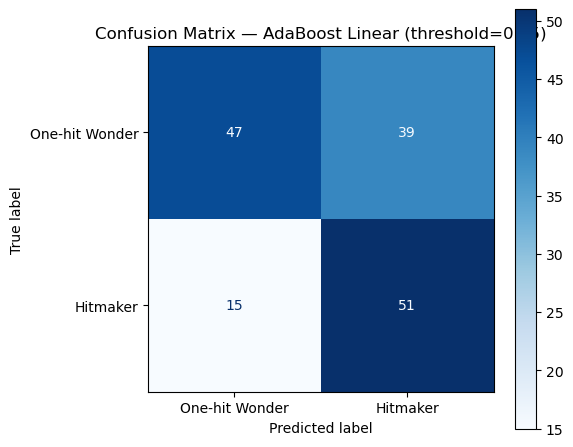

── Tuned threshold comparison ──
                       Threshold  N Features  Test AUC  Overfit Gap  Log Loss  Brier Score  Precision  Recall     F1
Model                                                                                                               
XGBoost (tight)             0.39          10     0.757        0.015     0.593        0.203      0.593   0.773  0.671
CatBoost (Mid)              0.40          12     0.770        0.022     0.576        0.195      0.607   0.773  0.680
AdaBoost Linear (n=5)       0.35           5     0.746        0.007     0.607        0.207      0.652   0.652  0.652
AdaBoost Tree (n=7)         0.45           7     0.758        0.029     0.576        0.196      0.613   0.742  0.671


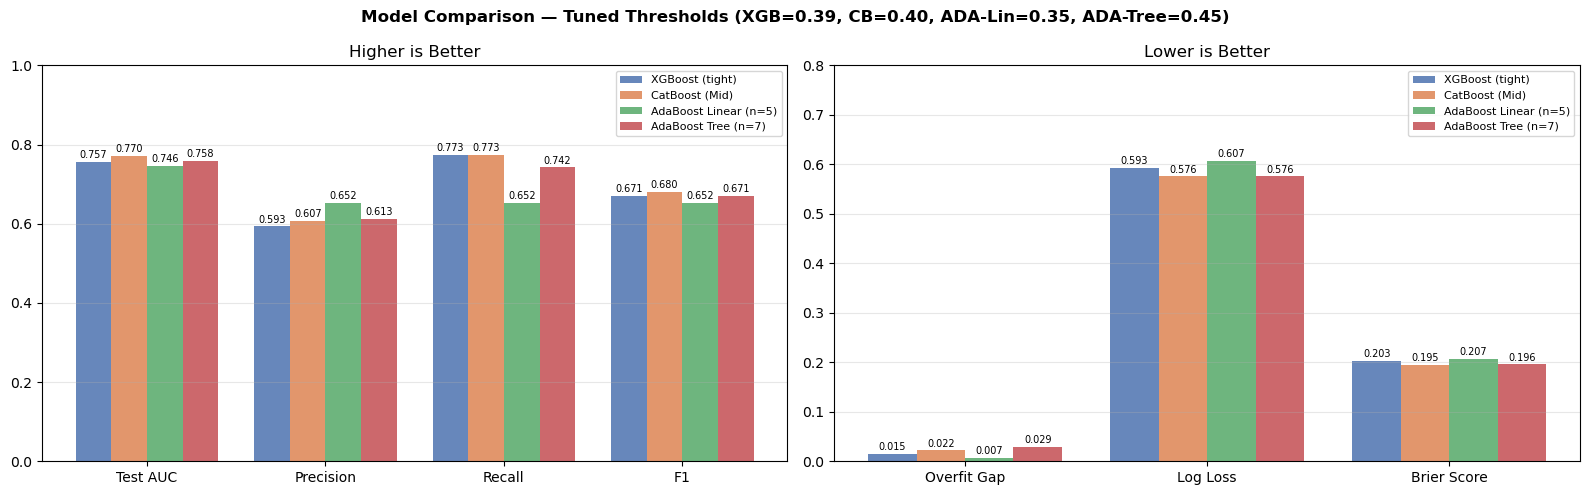

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

thresh_ada = 0.35
y_pred_tuned = (y_proba >= thresh_ada).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_tuned).ravel()

print(f'Threshold: {thresh_ada}')
print(f'TP={tp}  FP={fp}  FN={fn}  TN={tn}')
print()
print(classification_report(y_test, y_pred_tuned, target_names=['One-hit Wonder', 'Hitmaker']))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuned,
    display_labels=['One-hit Wonder', 'Hitmaker'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Confusion Matrix — AdaBoost Linear (threshold={thresh_ada})')
plt.tight_layout()
plt.show()

# ── Model comparison table (tuned thresholds) ──
rows = [
    {'Model': 'XGBoost (tight)',        'Threshold': 0.39, 'N Features': 10,
     'Test AUC': 0.757, 'Overfit Gap': 0.015, 'Log Loss': 0.593, 'Brier Score': 0.203,
     'Precision': 0.593, 'Recall': 0.773, 'F1': 0.671},
    {'Model': 'CatBoost (Mid)',          'Threshold': 0.40, 'N Features': 12,
     'Test AUC': 0.770, 'Overfit Gap': 0.022, 'Log Loss': 0.576, 'Brier Score': 0.195,
     'Precision': 0.607, 'Recall': 0.773, 'F1': 0.680},
    {'Model': 'AdaBoost Linear (n=5)', 'Threshold': thresh_ada, 'N Features': 5,
     'Test AUC': 0.746, 'Overfit Gap': 0.007, 'Log Loss': 0.607, 'Brier Score': 0.207,
     'Precision': 0.652, 'Recall': 0.652, 'F1': 0.652},
    {'Model': 'AdaBoost Tree (n=7)',    'Threshold': 0.45, 'N Features': 7,
     'Test AUC': 0.758, 'Overfit Gap': 0.029, 'Log Loss': 0.576, 'Brier Score': 0.196,
     'Precision': 0.613, 'Recall': 0.742, 'F1': 0.671},
]

df_compare = pd.DataFrame(rows).set_index('Model')
print('── Tuned threshold comparison ──')
print(df_compare.to_string())

# ── Bar charts ──
models = ['XGBoost (tight)', 'CatBoost (Mid)', 'AdaBoost Linear (n=5)', 'AdaBoost Tree (n=7)']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Model Comparison — Tuned Thresholds (XGB=0.39, CB=0.40, ADA-Lin=0.35, ADA-Tree=0.45)',
             fontsize=12, fontweight='bold')

metrics_high = ['Test AUC', 'Precision', 'Recall', 'F1']
vals_high = [[df_compare.loc[m, k] for k in metrics_high] for m in models]

x = np.arange(len(metrics_high))
w = 0.20
for i, (m, v, c) in enumerate(zip(models, vals_high, colors)):
    axes[0].bar(x + (i - 1.5) * w, v, w, label=m, color=c, alpha=0.85)
    for j, val in enumerate(v):
        axes[0].text(x[j] + (i - 1.5) * w, val + 0.005, f'{val:.3f}',
                     ha='center', va='bottom', fontsize=7)
axes[0].set_xticks(x); axes[0].set_xticklabels(metrics_high)
axes[0].set_ylim(0, 1.0); axes[0].set_title('Higher is Better', fontsize=12)
axes[0].legend(fontsize=8); axes[0].grid(axis='y', alpha=0.3)

metrics_low = ['Overfit Gap', 'Log Loss', 'Brier Score']
vals_low = [[df_compare.loc[m, k] for k in metrics_low] for m in models]

x = np.arange(len(metrics_low))
for i, (m, v, c) in enumerate(zip(models, vals_low, colors)):
    axes[1].bar(x + (i - 1.5) * w, v, w, label=m, color=c, alpha=0.85)
    for j, val in enumerate(v):
        axes[1].text(x[j] + (i - 1.5) * w, val + 0.003, f'{val:.3f}',
                     ha='center', va='bottom', fontsize=7)
axes[1].set_xticks(x); axes[1].set_xticklabels(metrics_low)
axes[1].set_ylim(0, 0.8); axes[1].set_title('Lower is Better', fontsize=12)
axes[1].legend(fontsize=8); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


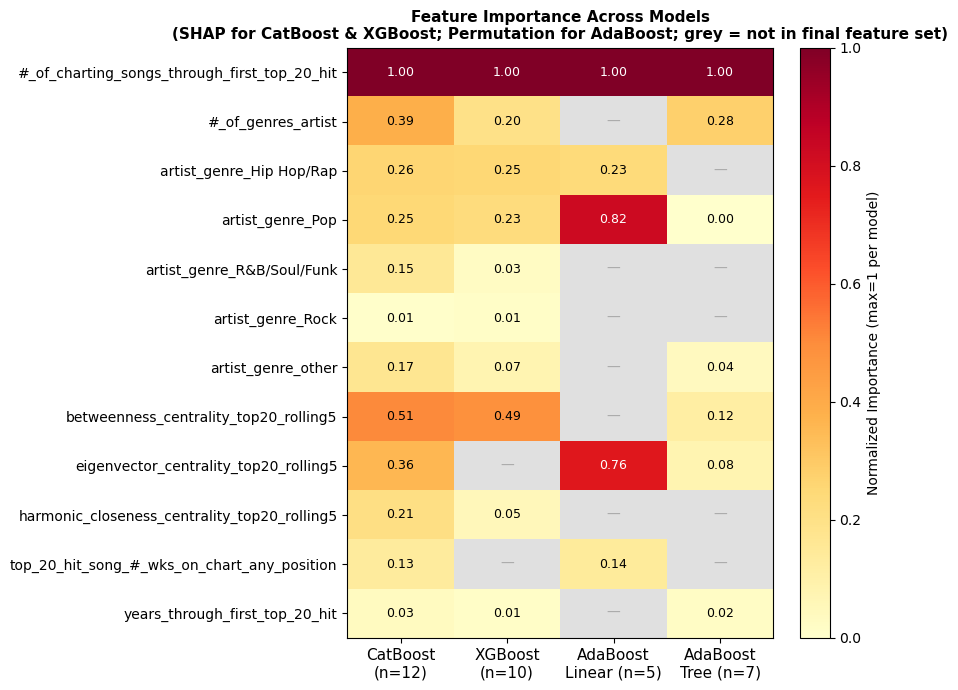

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Feature importances per model ──
# CatBoost: SHAP mean |value| (n=12, ml_sandbox_18)
catboost_imp = {
    '#_of_charting_songs_through_first_top_20_hit': 0.3210,
    'betweenness_centrality_top20_rolling5':        0.1630,
    '#_of_genres_artist':                           0.1240,
    'eigenvector_centrality_top20_rolling5':        0.1150,
    'artist_genre_Hip Hop/Rap':                     0.0830,
    'artist_genre_Pop':                             0.0790,
    'harmonic_closeness_centrality_top20_rolling5': 0.0670,
    'artist_genre_other':                           0.0550,
    'artist_genre_R&B/Soul/Funk':                   0.0490,
    'top_20_hit_song_#_wks_on_chart_any_position':  0.0430,
    'years_through_first_top_20_hit':               0.0110,
    'artist_genre_Rock':                            0.0020,
}

# XGBoost: SHAP mean |value| (n=10, ml_sandbox_17)
xgboost_imp = {
    '#_of_charting_songs_through_first_top_20_hit': 0.4348,
    'betweenness_centrality_top20_rolling5':        0.2111,
    'artist_genre_Hip Hop/Rap':                     0.1095,
    'artist_genre_Pop':                             0.0997,
    '#_of_genres_artist':                           0.0860,
    'artist_genre_other':                           0.0324,
    'harmonic_closeness_centrality_top20_rolling5': 0.0237,
    'artist_genre_R&B/Soul/Funk':                   0.0113,
    'artist_genre_Rock':                            0.0058,
    'years_through_first_top_20_hit':               0.0052,
}

# AdaBoost Linear: permutation importance (n=5, ml_sandbox_19)
adaboost_linear_imp = {
    '#_of_charting_songs_through_first_top_20_hit': 0.0605,
    'artist_genre_Pop':                             0.0497,
    'eigenvector_centrality_top20_rolling5':        0.0459,
    'artist_genre_Hip Hop/Rap':                     0.0142,
    'top_20_hit_song_#_wks_on_chart_any_position':  0.0083,
}

# AdaBoost Tree: permutation importance (n=7, ml_sandbox_20)
adaboost_tree_imp = {
    '#_of_charting_songs_through_first_top_20_hit': 0.1478,
    '#_of_genres_artist':                           0.0413,
    'betweenness_centrality_top20_rolling5':        0.0172,
    'eigenvector_centrality_top20_rolling5':        0.0111,
    'artist_genre_other':                           0.0054,
    'years_through_first_top_20_hit':               0.0029,
    'artist_genre_Pop':                             0.0004,
}

# ── Build normalized DataFrame (max=1 within each model) ──
models = {
    'CatBoost\n(n=12)':        catboost_imp,
    'XGBoost\n(n=10)':         xgboost_imp,
    'AdaBoost\nLinear (n=5)':  adaboost_linear_imp,
    'AdaBoost\nTree (n=7)':    adaboost_tree_imp,
}

all_features = sorted(set(f for imp in models.values() for f in imp))
df_imp = pd.DataFrame(
    {name: {f: imp.get(f, np.nan) for f in all_features} for name, imp in models.items()}
)
df_norm = df_imp.div(df_imp.max(axis=0), axis=1)

# Sort rows by mean normalized importance across models
df_norm = df_norm.loc[df_norm.mean(axis=1).sort_values(ascending=False).index]

# Shorten labels
short_labels = {
    '#_of_charting_songs_through_first_top_20_hit': 'charting_songs',
    'betweenness_centrality_top20_rolling5':        'betweenness',
    '#_of_genres_artist':                           '#_of_genres',
    'eigenvector_centrality_top20_rolling5':        'eigenvector',
    'harmonic_closeness_centrality_top20_rolling5': 'harmonic_closeness',
    'artist_genre_Pop':                             'genre_Pop',
    'artist_genre_Hip Hop/Rap':                     'genre_Hip Hop/Rap',
    'artist_genre_other':                           'genre_other',
    'artist_genre_R&B/Soul/Funk':                   'genre_R&B/Soul/Funk',
    'artist_genre_Rock':                            'genre_Rock',
    'top_20_hit_song_#_wks_on_chart_any_position':  'wks_on_chart',
    'years_through_first_top_20_hit':               'years_through',
}
df_norm = df_imp.div(df_imp.abs().max(axis=0), axis=1)

# ── Heatmap ──
cmap = plt.cm.YlOrRd.copy()
cmap.set_bad(color='#e0e0e0')

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(df_norm.values.astype(float), cmap=cmap, aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(df_norm.columns)))
ax.set_xticklabels(df_norm.columns, fontsize=11)
ax.set_yticks(range(len(df_norm.index)))
ax.set_yticklabels(df_norm.index, fontsize=10)

for i in range(len(df_norm.index)):
    for j in range(len(df_norm.columns)):
        val = df_norm.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=9, color='white' if val > 0.65 else 'black')
        else:
            ax.text(j, i, '—', ha='center', va='center', fontsize=10, color='#aaaaaa')

plt.colorbar(im, ax=ax, label='Normalized Importance (max=1 per model)')
ax.set_title('Feature Importance Across Models\n'
             '(SHAP for CatBoost & XGBoost; Permutation for AdaBoost; '
             'grey = not in final feature set)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


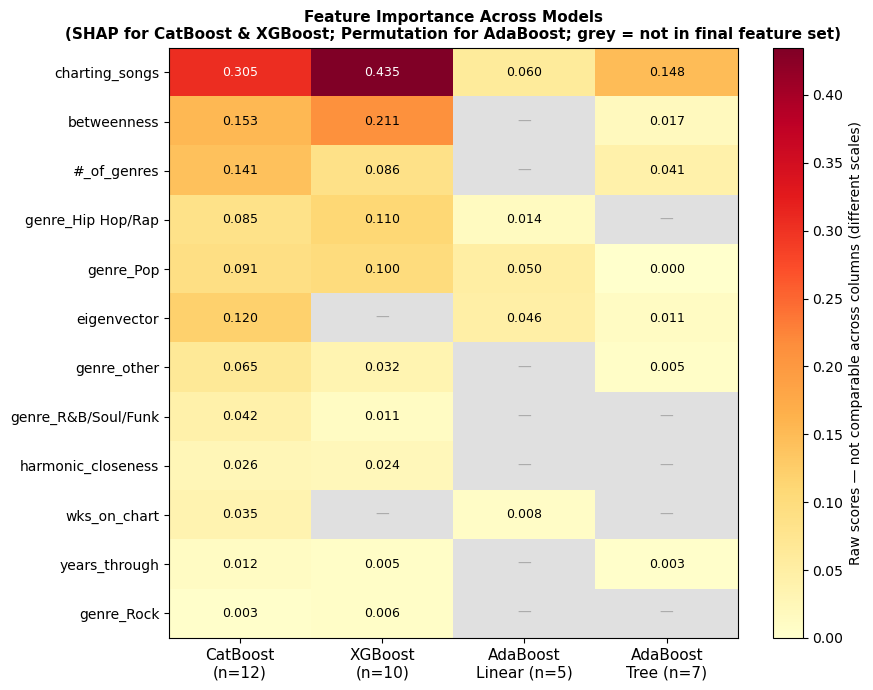

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Raw feature importances (un-normalized) ──
# CatBoost: SHAP mean |value| (n=12, ml_sandbox_18)
catboost_imp = {
    '#_of_charting_songs_through_first_top_20_hit':  0.3053,
    'betweenness_centrality_top20_rolling5':          0.1531,
    '#_of_genres_artist':                             0.1414,
    'eigenvector_centrality_top20_rolling5':          0.1196,
    'artist_genre_Pop':                               0.0906,
    'artist_genre_Hip Hop/Rap':                       0.0848,
    'artist_genre_other':                             0.0647,
    'artist_genre_R&B/Soul/Funk':                     0.0417,
    'top_20_hit_song_#_wks_on_chart_any_position':    0.0345,
    'harmonic_closeness_centrality_top20_rolling5':   0.0261,
    'years_through_first_top_20_hit':                 0.0116,
    'artist_genre_Rock':                              0.0025,
}

# XGBoost: SHAP mean |value| (n=10, ml_sandbox_17)
xgboost_imp = {
    '#_of_charting_songs_through_first_top_20_hit':  0.4348,
    'betweenness_centrality_top20_rolling5':          0.2111,
    'artist_genre_Hip Hop/Rap':                       0.1095,
    'artist_genre_Pop':                               0.0997,
    '#_of_genres_artist':                             0.0860,
    'artist_genre_other':                             0.0324,
    'harmonic_closeness_centrality_top20_rolling5':   0.0237,
    'artist_genre_R&B/Soul/Funk':                     0.0113,
    'artist_genre_Rock':                              0.0058,
    'years_through_first_top_20_hit':                 0.0052,
}

# AdaBoost Linear: permutation importance (n=5, ml_sandbox_19)
adaboost_linear_imp = {
    '#_of_charting_songs_through_first_top_20_hit':  0.0605,
    'artist_genre_Pop':                               0.0497,
    'eigenvector_centrality_top20_rolling5':          0.0459,
    'artist_genre_Hip Hop/Rap':                       0.0142,
    'top_20_hit_song_#_wks_on_chart_any_position':    0.0083,
}

# AdaBoost Tree: permutation importance (n=7, ml_sandbox_20)
adaboost_tree_imp = {
    '#_of_charting_songs_through_first_top_20_hit':  0.1478,
    '#_of_genres_artist':                             0.0413,
    'betweenness_centrality_top20_rolling5':          0.0172,
    'eigenvector_centrality_top20_rolling5':          0.0111,
    'artist_genre_other':                             0.0054,
    'years_through_first_top_20_hit':                 0.0029,
    'artist_genre_Pop':                               0.0004,
}

# ── Build DataFrame ──
models = {
    'CatBoost\n(n=12)':        catboost_imp,
    'XGBoost\n(n=10)':         xgboost_imp,
    'AdaBoost\nLinear (n=5)':  adaboost_linear_imp,
    'AdaBoost\nTree (n=7)':    adaboost_tree_imp,
}

all_features = sorted(set(f for imp in models.values() for f in imp))
df_imp = pd.DataFrame(
    {name: {f: imp.get(f, np.nan) for f in all_features} for name, imp in models.items()}
)

# Sort rows by mean importance (ignoring NaN)
df_imp = df_imp.loc[df_imp.mean(axis=1).sort_values(ascending=False).index]

short_labels = {
    '#_of_charting_songs_through_first_top_20_hit': 'charting_songs',
    'betweenness_centrality_top20_rolling5':        'betweenness',
    '#_of_genres_artist':                           '#_of_genres',
    'eigenvector_centrality_top20_rolling5':        'eigenvector',
    'harmonic_closeness_centrality_top20_rolling5': 'harmonic_closeness',
    'artist_genre_Pop':                             'genre_Pop',
    'artist_genre_Hip Hop/Rap':                     'genre_Hip Hop/Rap',
    'artist_genre_other':                           'genre_other',
    'artist_genre_R&B/Soul/Funk':                   'genre_R&B/Soul/Funk',
    'artist_genre_Rock':                            'genre_Rock',
    'top_20_hit_song_#_wks_on_chart_any_position':  'wks_on_chart',
    'years_through_first_top_20_hit':               'years_through',
}
df_imp.index = [short_labels.get(f, f) for f in df_imp.index]

# ── Heatmap ──
cmap = plt.cm.YlOrRd.copy()
cmap.set_bad(color='#e0e0e0')

vmax = df_imp.max().max()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(df_imp.values.astype(float), cmap=cmap, aspect='auto', vmin=0, vmax=vmax)

ax.set_xticks(range(len(df_imp.columns)))
ax.set_xticklabels(df_imp.columns, fontsize=11)
ax.set_yticks(range(len(df_imp.index)))
ax.set_yticklabels(df_imp.index, fontsize=10)

for i in range(len(df_imp.index)):
    for j in range(len(df_imp.columns)):
        val = df_imp.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                    fontsize=9, color='white' if val > 0.6 * vmax else 'black')
        else:
            ax.text(j, i, '—', ha='center', va='center', fontsize=10, color='#aaaaaa')

plt.colorbar(im, ax=ax, label='Raw scores — not comparable across columns (different scales)')
ax.set_title('Feature Importance Across Models\n'
             '(SHAP for CatBoost & XGBoost; Permutation for AdaBoost; '
             'grey = not in final feature set)',
             fontsize=11, fontweight='bold')

plt.subplots_adjust(right=0.78)
plt.tight_layout()
plt.show()
